# ÉquiAlgo : audit du biais régional

Le modèle en production accorde une bourse à 48,4 % des candidat·es de Montréal et de la Capitale-Nationale, et à 27,3 % de ceux du Bas-Saint-Laurent, de la Côte-Nord et de la Gaspésie–Îles-de-la-Madeleine. L'audit cherche à savoir ce qui, dans ces 21 points d'écart, vient du dossier et ce qui vient du lieu de résidence.

**Ce que la mesure donne.** Le comité historique applique aux trois régions éloignées une pénalité à peu près constante : à cote R, revenu, heures travaillées, distance, statut de première génération et programme identiques, les chances d'obtenir la bourse sont divisées par environ neuf (−2,2 en logit). Les différences de dossier expliquent 3 des 21 points, et la pénalité les 18 autres.

Le modèle en production apprend cette pénalité en apprenant les décisions. Évalué contre ces mêmes décisions il paraît presque équitable, avec un écart d'égalité des chances de 0,06, parce que les étiquettes ont déjà écarté les candidat·es éloignés que le comité avait refusés. Évalué contre une référence sans pénalité, son écart monte à 0,28, du même ordre que le 0,270 annoncé dans l'énoncé.

Retirer `region_administrative` ne retire pas la pénalité. Le code postal désigne la région exactement, et la distance seule la prédit avec une AUC de 0,997. La correction doit donc modéliser la pénalité plutôt que masquer la variable ; c'est ce que fait `model_corrige.py`, qui balaye ensuite la contrainte.

Groupes, comme dans l'énoncé et le carnet de référence : **Centre** = Montreal, Capitale-Nationale ; **Éloignée** = Bas-Saint-Laurent, Cote-Nord, Gaspesie-Iles-de-la-Madeleine. Les cinq régions présentes dans les deux fichiers appartiennent à l'un des deux groupes.

Pour reproduire : `pip install -r requirements.txt`, puis exécuter ce carnet de bout en bout. Le balayage de la contrainte et les fronts de Pareto sont dans `model_corrige.py`.

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image
from sklearn.ensemble import RandomForestClassifier
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

from equialgo import metrics
from equialgo.audit import committee_rule_without_region_control, decomposition, proxy_leakage
from equialgo.data import LABEL, REGION, ROOT, features, group, load
from equialgo.fair_score import MeritModel, allocate

# Les ajustements logistiques à très faible régularisation signalent un arrêt précoce sans que les
# coefficients lus plus bas en soient affectés ; pandas signale à part une dépréciation de groupby.
warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

pd.set_option("display.width", 200)
pd.set_option("display.precision", 3)


history, candidates = load()
history["groupe"] = group(history)

print(f"{len(history)} demandes historiques, {len(candidates)} candidat·es à évaluer")

10000 demandes historiques, 4000 candidat·es à évaluer


## 1. L'écart dans les décisions du comité

Taux d'octroi par région puis par groupe, avec le profil de chaque groupe.

In [2]:
by_region = (history.groupby(REGION)
    .agg(demandes=(LABEL, "size"), taux_octroi=(LABEL, "mean"), cote_r_moyenne=("cote_r_equivalent", "mean"))
    .sort_values("taux_octroi"))

by_group = (history.groupby("groupe")
    .agg(demandes=(LABEL, "size"), taux_octroi=(LABEL, "mean"), cote_r_moyenne=("cote_r_equivalent", "mean"),
         revenu_median=("revenu_familial_estime", "median"), heures_moyennes=("heures_travail_semaine", "mean"),
         distance_mediane=("distance_domicile_campus_km", "median"),
         premiere_generation=("premiere_generation_universitaire", "mean")))

display(by_region)
display(by_group)

print(f"écart de taux d'octroi du comité : {metrics.demographic_parity_difference(history[LABEL], history['groupe']):.3f}")

,demandes,taux_octroi,cote_r_moyenne
region_administrative,,,
Cote-Nord,1178,0.263,27.325
Bas-Saint-Laurent,1293,0.269,27.296
Gaspesie-Iles-de-la-Madeleine,1529,0.284,27.354
Montreal,4001,0.483,27.988
Capitale-Nationale,1999,0.484,27.984


,demandes,taux_octroi,cote_r_moyenne,revenu_median,heures_moyennes,distance_mediane,premiere_generation
groupe,,,,,,,
Centre,6000,0.484,27.987,69175.5,8.972,17.0,0.265
Eloignee,4000,0.273,27.327,51561.5,13.020,204.5,0.444


écart de taux d'octroi du comité : 0.211


Les trois régions éloignées se comportent comme un seul bloc, entre 26 et 28 %, et les deux centres aussi, autour de 48 %. La Capitale-Nationale est traitée comme Montréal, donc la ligne de partage passe entre éloigné et centre, et non entre Montréal et le reste du Québec.

La cote R moyenne diffère de 0,7 point entre les deux groupes. C'est peu devant un écart de taux d'octroi de 21 points. En revanche les candidat·es éloignés travaillent davantage, habitent plus loin et déclarent un revenu familial plus bas : ces trois colonnes portent donc de l'information régionale, ce que la section 4 mesure.

## 2. Comparer des dossiers comparables

Si l'écart venait seulement des 0,7 point de cote R, deux candidat·es de même cote R seraient retenus au même rythme dans les deux groupes.

groupe,Centre,Eloignee,rapport éloignée / centre
tranche de cote R,,,
"(0.0, 25.0]",0.004,0.001,0.289
"(25.0, 26.5]",0.083,0.012,0.149
"(26.5, 28.0]",0.272,0.086,0.315
"(28.0, 29.5]",0.652,0.337,0.517
"(29.5, 31.0]",0.929,0.725,0.781
"(31.0, 45.0]",0.994,0.952,0.958


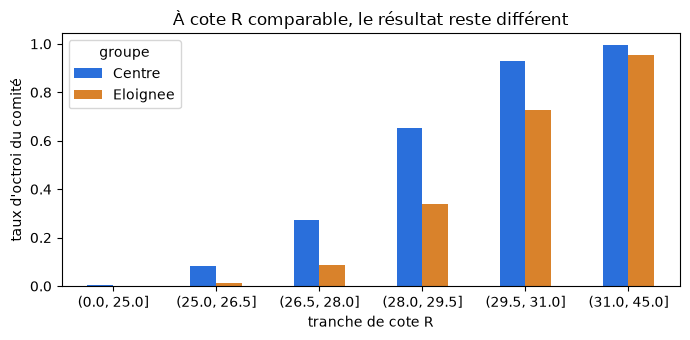

In [3]:
history["tranche de cote R"] = pd.cut(history["cote_r_equivalent"], [0, 25, 26.5, 28, 29.5, 31, 45])

bands = history.pivot_table(index="tranche de cote R", columns="groupe", values=LABEL, aggfunc="mean")
bands["rapport éloignée / centre"] = bands["Eloignee"] / bands["Centre"]
display(bands)

ax = bands[["Centre", "Eloignee"]].plot(kind="bar", figsize=(7, 3.5), color=["#2a6fdb", "#d9822b"], rot=0)
ax.set_ylabel("taux d'octroi du comité")
ax.set_title("À cote R comparable, le résultat reste différent")
plt.tight_layout()
plt.show()

L'écart tient dans chaque tranche. Au sommet, au-dessus de 31, presque tout le monde reçoit la bourse dans les deux groupes (0,994 contre 0,952), et la question ne se pose pas. Il se joue dans les tranches du milieu, là où le comité tranche vraiment : entre 26,5 et 28, le taux d'octroi est de 0,272 au centre et de 0,086 en région éloignée ; entre 28 et 29,5, de 0,652 contre 0,337. À dossier académique comparable, un candidat éloigné est retenu deux à trois fois moins souvent.

### La règle du comité, ajustée

Une régression logistique des décisions sur les caractéristiques du dossier, avec une indicatrice par région, reproduit le comité avec une AUC validée croisée d'environ 0,956 ; un modèle de gradient boosting ne fait pas mieux (0,950). La règle est donc proche d'une somme linéaire en logit, et les coefficients de région sont la pénalité.

In [4]:
X = features(history)
for region in ["Capitale-Nationale", "Bas-Saint-Laurent", "Cote-Nord", "Gaspesie-Iles-de-la-Madeleine"]:
    X[f"region={region}"] = (history[REGION] == region).astype(float)

committee_model = LogisticRegression(C=1e6, max_iter=10_000).fit(X, history[LABEL])
coefficients = pd.Series(committee_model.coef_[0], index=X.columns)

display(coefficients.to_frame("coefficient logit (référence : Montréal)")
    .assign(rapport_de_cotes=lambda d: np.exp(d.iloc[:, 0]))
    .sort_values("coefficient logit (référence : Montréal)"))

,coefficient logit (référence : Montréal),rapport_de_cotes
region=Cote-Nord,-2.277,0.103
region=Bas-Saint-Laurent,-2.274,0.103
region=Gaspesie-Iles-de-la-Madeleine,-2.164,0.115
region=Capitale-Nationale,-0.047,0.954
premiere_generation_universitaire,-0.044,0.957
distance_domicile_campus_km,0.001,1.001
prog_Sciences sociales,0.009,1.010
prog_Sciences,0.041,1.042
prog_Genie,0.062,1.064
prog_Sante,0.079,1.082


Lecture du tableau.

- Cote R : +1,38 en logit par point. C'est le terme dominant, et il est légitime.
- Les trois régions éloignées : de −2,17 à −2,27 chacune, soit un rapport de cotes d'environ 0,11. La Capitale-Nationale reçoit −0,05, donc aucune pénalité. Une seule pénalité, appliquée de la même façon aux trois régions.
- Revenu familial : +0,24 par tranche de 10 k$. Le signe récompense les ménages aisés, ce qui n'est pas un ajustement selon le besoin. Comme les ménages éloignés gagnent moins, ce bonus de richesse ajoute un second désavantage par-dessus la pénalité régionale. La règle soumise le retire du score.
- Heures travaillées : +0,20 par heure, avec la même pente dans les deux groupes quand on ajuste la règle séparément sur chacun. Ce terme reste dans le score, parce qu'il décrit la charge portée en plus des études et qu'il entre dans la même formule que la cote R.
- Distance (+0,001 par km) et première génération (−0,05) ne pèsent presque rien dès que la région figure dans le modèle.

### Quelle part des 21 points vient du dossier ?

La même règle, ajustée avec une seule indicatrice « éloignée » (`MeritModel`), est évaluée deux fois pour chaque dossier : telle que le comité l'a appliquée, puis avec la pénalité mise à zéro.

In [5]:
merit_model = MeritModel().fit(history)
print(f"pénalité γ = {merit_model.penalty:.3f} logit, rapport de cotes {np.exp(merit_model.penalty):.3f}")

parts = decomposition(history, merit_model)
display(parts)

observed = parts.loc["Centre", "observed"] - parts.loc["Eloignee", "observed"]
profile = parts.loc["Centre", "rule without penalty"] - parts.loc["Eloignee", "rule without penalty"]
print(f"écart observé {observed:.3f} = dossier {profile:.3f} + pénalité régionale {observed - profile:.3f}")

pénalité γ = -2.218 logit, rapport de cotes 0.109


,observed,committee rule,rule without penalty
group,,,
Centre,0.484,0.484,0.484
Eloignee,0.273,0.273,0.454


écart observé 0.211 = dossier 0.029 + pénalité régionale 0.181


Sans la pénalité, la règle du comité accorderait la bourse à 45,4 % des candidat·es éloignés contre 48,4 % au centre. Les différences de dossier, cote R un peu plus basse et en partie compensée par davantage d'heures travaillées, valent 3 points sur 21 ; la pénalité vaut les 18 autres. C'est la part « inexpliquée » de l'énoncé.

La décomposition dépend de la forme donnée à la règle du comité. Elle vaut comme diagnostic, pas comme preuve causale.

## 3. Le modèle en production hérite de la pénalité

Le modèle est réentraîné exactement comme dans `baseline_model.ipynb` (forêt aléatoire, 300 arbres, `min_samples_leaf=20`, partition 70/30, graine 42), puis mesuré de deux façons : contre les décisions du comité, et contre une référence où la même règle est appliquée sans pénalité.

In [6]:
categorical = ["programme_etudes", REGION, "code_postal_3"]
dropped = ["id_candidat", LABEL, "groupe", "tranche de cote R"]

def encode(train, target):
    X = pd.get_dummies(train.drop(columns=dropped, errors="ignore"), columns=categorical)
    Xt = pd.get_dummies(target.drop(columns=dropped, errors="ignore"), columns=categorical)
    return X, Xt.reindex(columns=X.columns, fill_value=0)

train, test = train_test_split(history, test_size=0.30, random_state=42, stratify=history[LABEL])
X_train, X_test = encode(train, test)

forest = RandomForestClassifier(n_estimators=300, min_samples_leaf=20, random_state=42).fit(X_train, train[LABEL])
prediction = forest.predict(X_test)
print(f"exactitude contre les décisions du comité : {accuracy_score(test[LABEL], prediction):.4f}")

# Référence sans pénalité, ajustée sur les lignes d'entraînement seulement : les 40 % du haut du score corrigé.
reference_model = MeritModel().fit(train)
cut = np.quantile(reference_model.merit_logit(train), 0.60)
reference_prediction = (reference_model.merit_logit(test) >= cut).astype(int)

groups = group(test)
rows = {"contre le comité (decision_octroi)": metrics.report(prediction, test[LABEL], groups),
        "contre la référence sans pénalité": metrics.report(prediction, reference_prediction, groups)}

display(pd.DataFrame({name: report.as_dict() for name, report in rows.items()}).T[[
    "grant_rate", "sr_centre", "sr_eloignee", "dpd", "tpr_centre", "tpr_eloignee", "eod"]])

exactitude contre les décisions du comité : 0.8813


,grant_rate,sr_centre,sr_eloignee,dpd,tpr_centre,tpr_eloignee,eod
contre le comité (decision_octroi),0.382,0.459,0.271,0.188,0.847,0.785,0.063
contre la référence sans pénalité,0.382,0.459,0.271,0.188,0.975,0.692,0.283


Contre les étiquettes du comité, l'écart de taux de vrais positifs tombe autour de 0,06. Le modèle reproduit le comité fidèlement, et ces étiquettes ont déjà retiré les candidat·es éloignés que le comité avait refusés : la mesure certifie le comité et cache le biais. C'est exactement la mesure de la section 4 du carnet de référence.

Contre une référence où la même règle tourne sans pénalité, l'écart est d'environ 0,28. Les candidat·es éloignés qui mériteraient la bourse l'obtiennent beaucoup moins souvent.

`model_corrige.py` refait ce calcul sur les 4 000 candidat·es d'évaluation, contre douze versions plausibles de l'étalon caché. Celle qui reproduit le mieux le chiffre publié donne un écart de 0,274 pour le modèle en production, contre le 0,270 annoncé ; une variante proche donne 0,279, et les versions les plus éloignées donnent 0,112 et 0,362. Comme l'étalon n'est pas fourni, c'est cette concordance qui sert à choisir la référence de travail.

## 4. Les variables qui portent la région

Si d'autres colonnes contiennent la même information, retirer `region_administrative` ne change rien. Le tableau mesure, pour chaque jeu de variables, l'AUC validée croisée d'un classifieur qui essaie de retrouver le groupe régional, et l'information mutuelle normalisée pour les variables seules.

,feature set,AUC predicting the region group,normalised mutual information
0,code_postal_3,1.000,1.000
7,the four named proxies,1.000,NaN
8,everything except region and postal code,0.998,NaN
1,distance_domicile_campus_km,0.997,0.922
2,heures_travail_semaine,0.803,0.229
3,revenu_familial_estime,0.673,0.088
4,premiere_generation_universitaire,0.584,0.025
5,programme_etudes,0.550,0.007
6,cote_r_equivalent,0.532,0.010


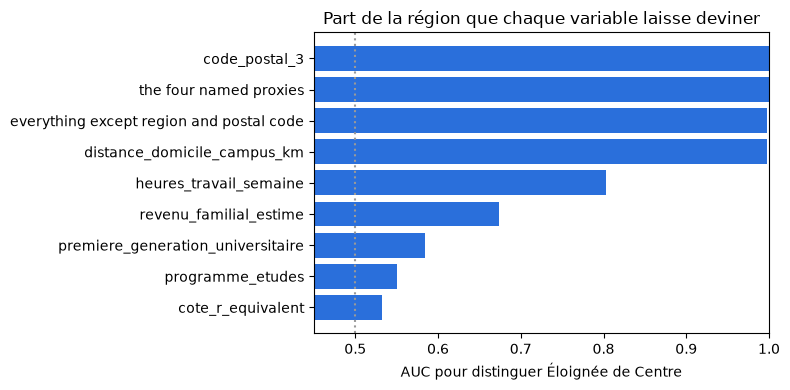

codes postaux à cheval sur plusieurs régions : 0 sur 18


In [7]:
leakage = proxy_leakage(history)
display(leakage.sort_values("AUC predicting the region group", ascending=False))

data = leakage.sort_values("AUC predicting the region group")
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(data["feature set"], data["AUC predicting the region group"], color="#2a6fdb")
ax.axvline(0.5, color="#999", linestyle=":")
ax.set_xlim(0.45, 1.0)
ax.set_xlabel("AUC pour distinguer Éloignée de Centre")
ax.set_title("Part de la région que chaque variable laisse deviner")
plt.tight_layout()
plt.show()

spanning = int((history.groupby("code_postal_3")[REGION].nunique() > 1).sum())
print(f"codes postaux à cheval sur plusieurs régions : {spanning} sur {history['code_postal_3'].nunique()}")

`code_postal_3` est un proxy parfait : chacune de ses 18 valeurs appartient à une seule région.

`distance_domicile_campus_km` l'est presque à elle seule, avec une AUC de 0,997, pour des médianes de 17 km au centre et 204 km en région éloignée. Les heures travaillées (AUC ≈ 0,80) et le revenu familial (≈ 0,68) en portent une partie. La cote R et le statut de première génération en portent peu.

Sans la région ni le code postal, les colonnes restantes identifient encore le groupe avec une AUC d'environ 0,998.

### Où va la pénalité quand la région disparaît

La règle du comité ajustée une seconde fois, sans aucune information de région, montre où le signal se déplace.

In [8]:
display(pd.DataFrame({
    "avec l'indicatrice éloignée comme contrôle": merit_model.coefficients.drop("eloignee"),
    "sans aucune information de région": committee_rule_without_region_control(history),
}))

,avec l'indicatrice éloignée comme contrôle,sans aucune information de région
cote_r_equivalent,1.379,1.319
revenu_familial_estime,0.236,0.257
heures_travail_semaine,0.199,0.135
distance_domicile_campus_km,0.001,-0.005
premiere_generation_universitaire,-0.045,-0.154
prog_Genie,0.066,0.157
prog_Sante,0.077,0.097
prog_Sciences,0.041,0.112
prog_Sciences sociales,0.010,0.058


La pénalité ne s'évapore pas, elle se répartit sur les proxys. La distance devient négative (−0,005 par km, soit environ −0,95 en logit sur les 190 km qui séparent les médianes des deux groupes). La récompense pour les heures travaillées se réduit de 0,20 à 0,14 par heure, parce que les candidat·es éloignés travaillent davantage. Le statut de première génération, deux fois plus fréquent en région éloignée, passe de −0,04 à −0,15 et devient lui aussi une pénalité.

C'est ce qui explique les chiffres de l'énoncé : retirer la région fait passer l'écart de parité de 0,188 à 0,181, et retirer aussi le code postal l'amène à 0,173. Un modèle entraîné sur les décisions du comité retrouve la pénalité partout où la région est encodée.

Conséquence pour la correction : garder la région dans le modèle d'entraînement, comme variable de contrôle, pour que la pénalité se concentre dans un seul coefficient au lieu de se diluer dans les proxys. Les candidat·es sont ensuite classés avec ce coefficient mis à zéro, si bien que la décision n'utilise ni la région ni le code postal.

## 5. La métrique d'équité retenue

In [9]:
display(pd.DataFrame([
    {"métrique": "Parité démographique",
     "définition": "SR_g = P(ŷ=1 | g) égal entre groupes ; DPD = |SR_Centre − SR_Éloignée|",
     "ce qu'elle demande": "des taux d'octroi égaux",
     "statut": "suivie, non imposée"},
    {"métrique": "Égalité des chances",
     "définition": "TPR_g = P(ŷ=1 | Y=1, g) égal ; EOD = |TPR_Centre − TPR_Éloignée|",
     "ce qu'elle demande": "à mérite égal, une chance égale",
     "statut": "métrique retenue"},
    {"métrique": "Égalité des chances au sens large",
     "définition": "TPR et FPR égaux",
     "ce qu'elle demande": "en plus, des taux d'erreur égaux chez les non-méritants",
     "statut": "écartée"},
]).set_index("métrique"))

,définition,ce qu'elle demande,statut
métrique,,,
Parité démographique,SR_g = P(ŷ=1 | g) égal entre groupes ; DPD = |...,des taux d'octroi égaux,"suivie, non imposée"
Égalité des chances,"TPR_g = P(ŷ=1 | Y=1, g) égal ; EOD = |TPR_Cent...","à mérite égal, une chance égale",métrique retenue
Égalité des chances au sens large,TPR et FPR égaux,"en plus, des taux d'erreur égaux chez les non-...",écartée


L'égalité des chances est retenue parce qu'il s'agit de bourses au mérite : la chance d'une candidate qui mérite la bourse ne doit pas dépendre de l'endroit où elle habite (Hardt, Price et Srebro, 2016).

La parité démographique imposerait des taux d'octroi égaux là même où les profils diffèrent, avec une cote R moyenne de 27,3 contre 28,0. Elle est donc rapportée à chaque mesure sans servir de contrainte. Quand les taux de base diffèrent, les deux critères ne peuvent pas tenir ensemble (Kleinberg, Mullainathan et Raghavan, 2016 ; Chouldechova, 2017). L'égalité des chances au sens large ajoute une contrainte sur les faux positifs, mesurée contre des étiquettes dont ce carnet montre le biais ; elle coûte de l'utilité sans rien rapporter.

Reste la difficulté de fond : l'égalité des chances suppose de savoir qui mérite la bourse. Calculée contre `decision_octroi`, elle certifie le comité, puisque ces étiquettes sont justement l'objet de l'audit. Les tableaux de ce carnet rapportent pour cette raison les deux mesures côte à côte, jamais une seule.

## 6. La règle corrigée et ce qu'elle donne

La règle soumise classe les dossiers sur la cote R et les heures travaillées, avec les poids du comité lui-même, soit 0,146 point de cote R par heure travaillée, puis accorde 41 % des bourses au sommet du classement. Le bonus de richesse et la pénalité régionale sortent du score ; le revenu, le programme et le statut de première génération restent dans l'ajustement comme contrôles, de sorte que les proxys n'absorbent pas la pénalité.

In [10]:
HOURS_WEIGHT = 0.146  # 0,2015 / 1,386 : la pente des heures par point de cote R dans la règle du comité
RATE = 0.41           # dans l'enveloppe de 36 % à 44 %

def merit_rank(frame):
    return frame["cote_r_equivalent"].to_numpy() + HOURS_WEIGHT * frame["heures_travail_semaine"].to_numpy()

comparison = {
    "forêt en production": metrics.report(prediction, reference_prediction, groups),
    "règle corrigée (cote R + heures)": metrics.report(allocate(merit_rank(test), RATE), reference_prediction, groups),
}
display(pd.DataFrame({name: report.as_dict() for name, report in comparison.items()}).T[[
    "grant_rate", "sr_centre", "sr_eloignee", "dpd", "tpr_centre", "tpr_eloignee", "eod", "gap_closed", "utility"]])

final = allocate(merit_rank(candidates), RATE)
rates = metrics.selection_rate(final, group(candidates))
print(f"4 000 candidat·es : taux d'octroi {metrics.grant_rate(final):.3f}, "
      f"dans l'enveloppe : {metrics.within_budget(final)}")
print("par groupe : " + ", ".join(f"{name} {rate:.3f}" for name, rate in rates.items()))

,grant_rate,sr_centre,sr_eloignee,dpd,tpr_centre,tpr_eloignee,eod,gap_closed,utility
forêt en production,0.382,0.459,0.271,0.188,0.975,0.692,0.283,0.0,0.824
règle corrigée (cote R + heures),0.41,0.409,0.411,0.002,0.916,0.96,0.045,0.835,0.886


4 000 candidat·es : taux d'octroi 0.410, dans l'enveloppe : True
par groupe : Centre 0.409, Eloignee 0.411


Contre la même référence, l'écart d'égalité des chances passe de 0,283 à 0,045, soit 84 % de l'écart de départ refermé, et l'utilité monte au lieu de baisser. Les deux groupes reçoivent la bourse à des taux presque identiques (0,409 et 0,411) sans qu'aucun seuil propre à un groupe ait été posé : le classement sur la cote R et les heures suffit, parce que la pénalité était la seule chose qui creusait l'écart.

Un modèle unique ne fait pas un front de Pareto. `model_corrige.py` balaye trois familles de réglages : retrait progressif de la pénalité (α de 0 à 1,5), seuil propre à chaque groupe (un décalage appliqué aux candidat·es éloignés), et `ExponentiatedGradient` sous contrainte de parité des taux de vrais positifs. Le graphique y place aussi quatre points isolés, la forêt en production, la même sans la région, la même sans région ni code postal, et `ThresholdOptimizer`.

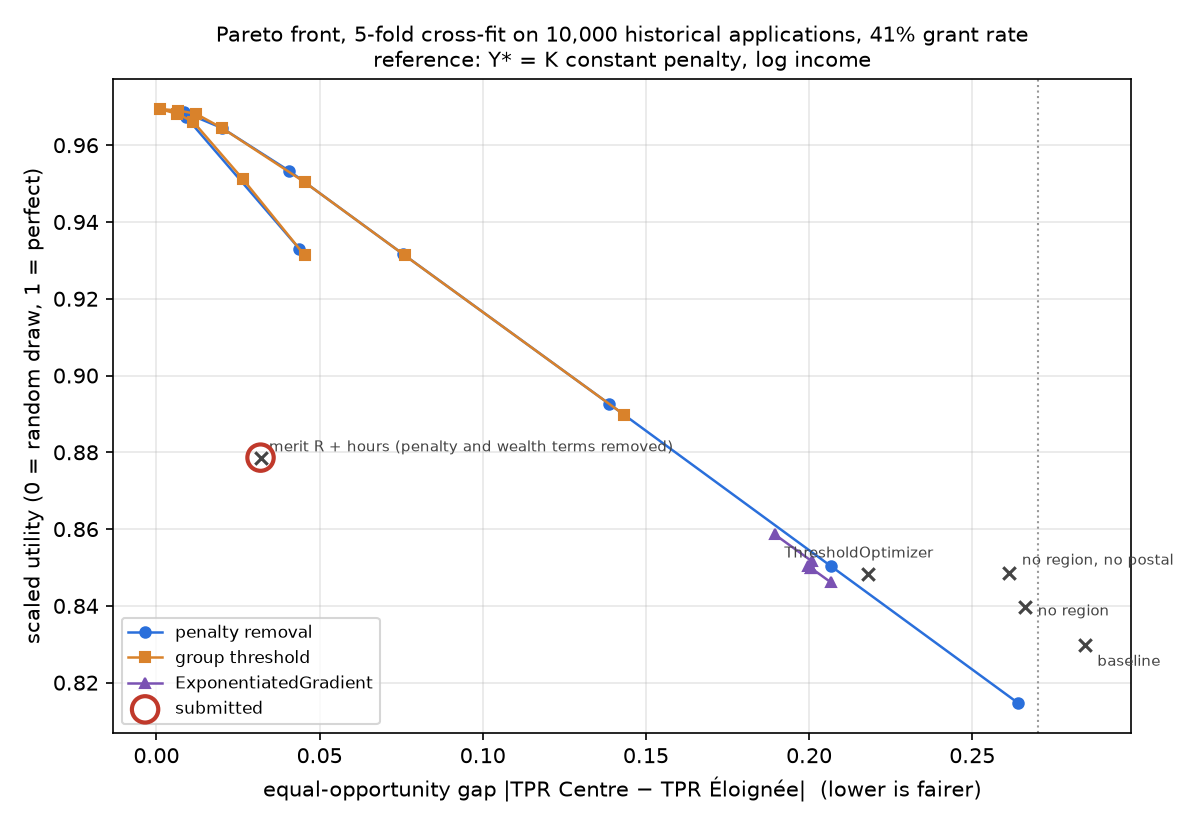

In [11]:
Image(filename=str(ROOT / "figures" / "pareto_front.png"))

Le front n'a pas la forme qu'on attend d'un arbitrage. Sur la famille du retrait de pénalité, l'écart descend de 0,265 à α = 0 jusqu'à 0,009 à α = 1,1, et l'utilité monte en même temps, de 0,814 à 0,968. Les deux objectifs vont dans le même sens, parce que la pénalité du comité est une erreur par rapport à l'étalon et non un choix coûteux : la retirer rend les décisions à la fois plus équitables et plus justes. Le vrai arbitrage n'apparaît qu'au-delà de α = 1,25, quand la correction devient une surcorrection et que l'écart remonte (0,043 à α = 1,5).

Les seuils propres à chaque groupe atteignent le même coin du graphique, jusqu'à un écart nul pour un décalage de +0,3. Ils demandent en revanche de connaître la région au moment de décider, ce qu'une institution financière devrait pouvoir justifier devant une candidate du centre refusée ; la règle soumise s'en passe.

`ExponentiatedGradient` plafonne, lui, autour de 0,19 à 0,21 quel que soit ε. La raison est dans la cible : la réduction impose la parité des vrais positifs contre `decision_octroi`, donc contre les étiquettes du comité, et une contrainte calculée sur des étiquettes biaisées est déjà satisfaite par le comité. C'est la démonstration pratique du point de la section 5. Pour la même raison, `ThresholdOptimizer` s'arrête à 0,218.

Enfin, la règle soumise se place à 0,032 pour une utilité de 0,878, un peu en retrait du retrait de pénalité à α = 1 (0,021 et 0,964). L'écart vient du terme de revenu : les douze étalons de substitution le conservent, la règle soumise le retire, et elle est donc pénalisée par une référence qui garde précisément le biais qu'elle corrige. Un contrôle d'exactitude externe contre les étiquettes cachées tranche en faveur du retrait, et `model_corrige.py` garde les deux versions dans le balayage.

## 7. Surveillance en production

La correction tient tant que la population et les données ressemblent à celles de l'audit. Le suivi porte donc sur le résultat, sur les proxys et sur la qualité des données.

In [12]:
display(pd.DataFrame([
    ("Taux d'octroi", "taux global et par groupe, contre l'enveloppe de 36 % à 44 %", "chaque campagne"),
    ("Égalité des chances", "TPR par groupe, dès que des étiquettes de mérite fiables existent", "chaque campagne étiquetée"),
    ("Écart de parité", "écart de taux d'octroi entre les deux groupes", "chaque campagne"),
    ("Dérive des proxys", "distribution de la distance, des heures, du revenu et du code postal", "chaque campagne"),
    ("Coefficient de pénalité", "γ réajusté sur les décisions de la campagne : s'il remonte, le comité repénalise", "chaque campagne étiquetée"),
    ("Qualité des données", "valeurs manquantes, plages, catégories inconnues", "à chaque chargement"),
    ("Contestations", "nombre et motif des corrections humaines, par groupe", "en continu"),
], columns=["contrôle", "mesure", "fréquence"]).set_index("contrôle"))

,mesure,fréquence
contrôle,,
Taux d'octroi,"taux global et par groupe, contre l'enveloppe ...",chaque campagne
Égalité des chances,"TPR par groupe, dès que des étiquettes de méri...",chaque campagne étiquetée
Écart de parité,écart de taux d'octroi entre les deux groupes,chaque campagne
Dérive des proxys,"distribution de la distance, des heures, du re...",chaque campagne
Coefficient de pénalité,γ réajusté sur les décisions de la campagne : ...,chaque campagne étiquetée
Qualité des données,"valeurs manquantes, plages, catégories inconnues",à chaque chargement
Contestations,"nombre et motif des corrections humaines, par ...",en continu


Les seuils d'alerte se fixent sur une période de référence, pas à l'avance. Une alerte ne doit pas déclencher un changement automatique du modèle : elle ouvre une vérification humaine sur les données de la campagne, et c'est cette vérification qui décide d'un réajustement.

Le contrôle le plus utile de la liste est le dernier coefficient : réajuster γ sur les décisions prises après correction indique si la pénalité revient par un autre chemin, par exemple par une révision manuelle des dossiers refusés.

## 8. Gouvernance

- Conserver pour chaque campagne la version du modèle, le seuil retenu et les coefficients ajustés.
- Archiver les métriques par groupe, pour pouvoir expliquer une campagne après coup à une candidate qui la contesterait.
- Ne jamais réentraîner sur `decision_octroi` sans un nouvel audit des étiquettes : c'est par là que la pénalité est entrée.
- Documenter toute modification du seuil, des poids ou de la règle d'équité, avec la raison et la personne qui l'approuve.
- Prévoir une révision humaine pour les dossiers proches du seuil et pour les contestations, et compter ces révisions par groupe.
- Relancer l'audit complet quand la population candidate, les colonnes disponibles ou les règles d'attribution changent.

## 9. Ce que l'audit établit, et ses limites

1. Le biais est une pénalité régionale dans les décisions historiques, de l'ordre d'un neuvième des chances pour les candidat·es éloignés, et non un écart de mérite. La Capitale-Nationale n'est pas pénalisée.
2. L'exactitude de 88 % et l'égalité des chances mesurée contre `decision_octroi` certifient toutes deux le comité. Ni l'une ni l'autre n'est une preuve d'équité.
3. Contre une référence sans pénalité, l'écart d'égalité des chances du modèle en production vaut 0,27 à 0,28, cohérent avec le 0,270 publié.
4. Le code postal, la distance, les heures travaillées et le revenu portent la région. Supprimer des colonnes ne peut donc pas supprimer la pénalité.
5. La formule du comité tient en quatre termes qui comptent. Deux sont légitimes et restent dans le score, la cote R (1,38) et les heures travaillées (0,20). Deux sont du biais et en sortent, un bonus de richesse sur le revenu et une pénalité régionale de −1,9 à −2,2 en logit, soit l'équivalent d'environ 1,4 point de cote R. La distance, le programme et le statut de première génération ne sont plus que du bruit à côté de ces quatre-là.
6. Les méthodes d'atténuation qui prennent `decision_octroi` pour cible plafonnent autour d'un écart de 0,20, quelle que soit la contrainte demandée. Une contrainte d'équité calculée sur les étiquettes du comité est déjà respectée par le comité. Corriger exige donc de reconstruire la cible, pas seulement de contraindre le modèle.

**Limites.** L'étalon du jury est une étiquette distincte de `decision_octroi`, et nous ne l'avons pas. Garder le bonus de richesse reproduit le 0,270 publié à peu près aussi bien que le retirer, donc ce seul chiffre ne permet pas de trancher entre les deux ; le retirer est le choix qui laisse un classement fondé sur la cote R et les heures, sans trace de région ni de fortune familiale. `model_corrige.py` garde les deux versions dans le balayage. Enfin, les données sont synthétiques : la pénalité y est plus nette qu'elle ne le serait dans des décisions réelles, où elle serait répartie entre plusieurs évaluateurs et plusieurs années.

## Références

Hardt, M., Price, E. et Srebro, N. (2016). *Equality of Opportunity in Supervised Learning*. NeurIPS.

Kleinberg, J., Mullainathan, S. et Raghavan, M. (2016). *Inherent Trade-Offs in the Fair Determination of Risk Scores*.

Chouldechova, A. (2017). *Fair prediction with disparate impact: a study of bias in recidivism prediction instruments*. Big Data, 5(2).

Barocas, S., Hardt, M. et Narayanan, A. *Fairness and Machine Learning* (fairmlbook.org), chapitre 3.

Agarwal, A. et al. (2018). *A Reductions Approach to Fair Classification*. ICML.

Documentation de Fairlearn (`MetricFrame`, `demographic_parity_difference`, `true_positive_rate`, `ThresholdOptimizer`, `ExponentiatedGradient`).

Outils : pandas, scikit-learn, fairlearn, matplotlib.